## Single cell data structures

### Intro and imports

In this notebook you will get comfortable using jupyter notebooks and learn how we store and interact with single cell gene expression (scRNA-seq) data

Jupyter notebook cells are either text ('markdown') or runnable code. You can run the code in a cell using cmd + enter (on mac) or ctrl + enter (on windows). Double cick on a cell to edit it

We will cover:

- counts matrices
- how to connect counts matrices with metadata using AnnData
- filter out low-quality cells and genes
- normalize and transform data
- reduce the dataset dimensions for visualization

First, import the required packages

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

Next, we'll configure our environment to print verbose output and to adjust figure sizes

In [ ]:
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, figsize=(5, 4))

### Toy data

#### Simple matrix

We store our counts data in a **counts matrix** -- rows correspond to cells and columns correspond to genes, and the value in a cell tells you how many counts of a **gene** were sequenced for particular **cell**

We use this data to understand how particular experimental conditions impact gene expression. Like with all data sets, we need to understand potential biases and sources of error to draw conclusions

We need efficient data structures and automation to process this data, because a typical experiment will be very large (~10k cells and 20k genes)

Let's construct a toy counts matrix with 5 genes and 6 cells. 

In [ ]:
counts = np.array([
    # GeneA  GeneB  GeneC  GeneD  GeneE
    [  10,    0,    200,    5,    300  ],  # cell_0
    [   8,    0,    180,    3,    290  ],  # cell_1
    [   0,  150,     10,  400,      2  ],  # cell_2
    [   0,  160,      5,  380,      1  ],  # cell_3
    [  12,    0,    210,    4,    310  ],  # cell_4
    [   0,  140,      8,  420,      3  ],  # cell_5
])

cell_names  = [f"cell_{i}" for i in range(6)]
gene_names  = ["GeneA", "GeneB", "GeneC", "GeneD", "GeneE"]

Now, we have a 2 dimensional array (cells are 1 dimension, genes are another dimension):

In [ ]:
counts

How many counts of Gene C does each cell have? Which cells are similar in terms of Gene C's expression?

#### Create AnnData

We can figure this out visually for a dataset containing 6 cells and 5 genes, but this is much more difficult when working with a real data set. To handle sequencing data, we use a data structure called AnnData (portmanteau for annotated data). It's a container for single-cell data in Python. You can thinking of it like an extendable spreadsheet

layers store RNA counts (cell x gene)

.obs: cell metadata (rows)

.var: gene metadata (cols)

.obsm: 2D cell data (embeddings: PCA, UMAP…)

.varm: 2D gene data

Let's turn our existing counts data into an AnnData object

In [ ]:
obs_df = pd.DataFrame({"cell_type": ["TypeA","TypeA","TypeB","TypeB","TypeA","TypeB"]},
                      index=cell_names)
var_df = pd.DataFrame({"highly_variable": [True, True, False, True, False]},
                      index=gene_names)

adata = ad.AnnData(X=counts, obs=obs_df, var=var_df)
print(adata)

#### Explore AnnData

1) Print the .obs (cell metadata dataframe)

2) Print the counts for cell_2 only. Hint: look at adata.X 

3. We want to compare how cell TypeA's expression of each gene compares to TypeB's expression of each gene. Can you print the average expression of each gene per-celltype?

4. Do you see any potential problems with comparing means? Hint: look at the total counts per cell, and think about the experimental context. What should we do to control for potential biases?

### Real dataset

#### Load data

Let's use the **PBMC 3k** dataset that's built in to scanpy: ~2,700 human blood cells, ~32,000 genes

In [ ]:
adata = sc.datasets.pbmc3k()

How many cells does this dataset have? How many genes?

Not every "cell" captured is a real, healthy cell. Some are:
 - **Empty droplets** (almost no counts)
 - **Doublets** (two cells stuck together — too many counts)
 - **Dying cells** (high mitochondrial gene expression)

Let's filter these out before doing any analysis.

Calculate qc metrics

- n_genes_by_counts = number of genes detected per cell

- total_counts      = total RNA molecules per cell

#### Quality control

In [ ]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

Plot these qc metrics

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(adata.obs["n_genes_by_counts"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Genes detected per cell")
axes[0].set_ylabel("# cells")
axes[1].hist(adata.obs["total_counts"], bins=50, color="salmon", edgecolor="white")
axes[1].set_xlabel("Total counts per cell")
plt.tight_layout()
plt.show()

In [ ]:
adata

Choose cutoffs for filtering. Let's say we expect ~3% of our cells to be doublets and ~5% to be empty droplets (no cells). How can we use these values to set cutoffs for filtering?

In [ ]:
MIN_GENES = 100
MAX_GENES = 1750

In [ ]:
sc.pp.filter_cells(adata, min_genes=MIN_GENES)
sc.pp.filter_cells(adata, max_genes=MAX_GENES)

In [ ]:
adata

Note: this is equivalent to filtering the dataframe manually (ex: adata = adata[adata.obs["n_genes_by_counts"] < MAX_GENES]), but scanpy provides a function to handle the underlying logic so that we don't have to think about it every time we filter a data set.

How did the size of the dataset change after filtering?

Let's remove genes that are only expressed in a few cells. These genes might be interesting, but we don't have enough data to draw conclusions about them

In [ ]:
sc.pp.filter_genes(adata, min_cells=50)

We're going to normalize/transform counts. Before doing so, let's save raw counts:

In [ ]:
adata.raw = adata.copy()

#### Normalize and transform

As we saw with the toy dataset example, some cells will be sequenced to a higher depth than others, so we cannot compare raw count values. Let's start by normalizing each cells to 10k total counts

In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)

Let's log transform counts as well:

In [ ]:
sc.pp.log1p(adata)

Look at how normalization and transformation impact expression of CD3D. CD3D encodes a subunit of the T-cell receptor/CD3 complex, which is required for T cell activation. Hint: adata.raw[:, "CD3D"].X vs adata[:, "CD3D"].X

Why do we add 1 before taking the log? What would happen to zeros otherwise?

In [ ]:
import numpy as np
np.log(0)

#### Dimensionality reduction

How do we approach a dataset with so many dimensions? How would you decide which genes are meaningful? 

If a gene is expressed uniformly across cells, it won't help us understand the differences between cells in different experimental conditions. To make the dataset more manageable and target the genes that will tell us something about the differences in cells, let's compute highly variable genes.

In [ ]:
sc.pp.highly_variable_genes(adata)
print(f"{adata.var.highly_variable.sum()} highly variable genes selected")

Let's create a subset AnnData object where we just select the highly variable genes and then compute the principal components

In [ ]:
adata_hvg = adata[:, adata.var.highly_variable].copy()

Principal components capture the primary axis of variation, so rather than working with counts data, we're grouping cells together in space based on the patterns of expression of **many** genes

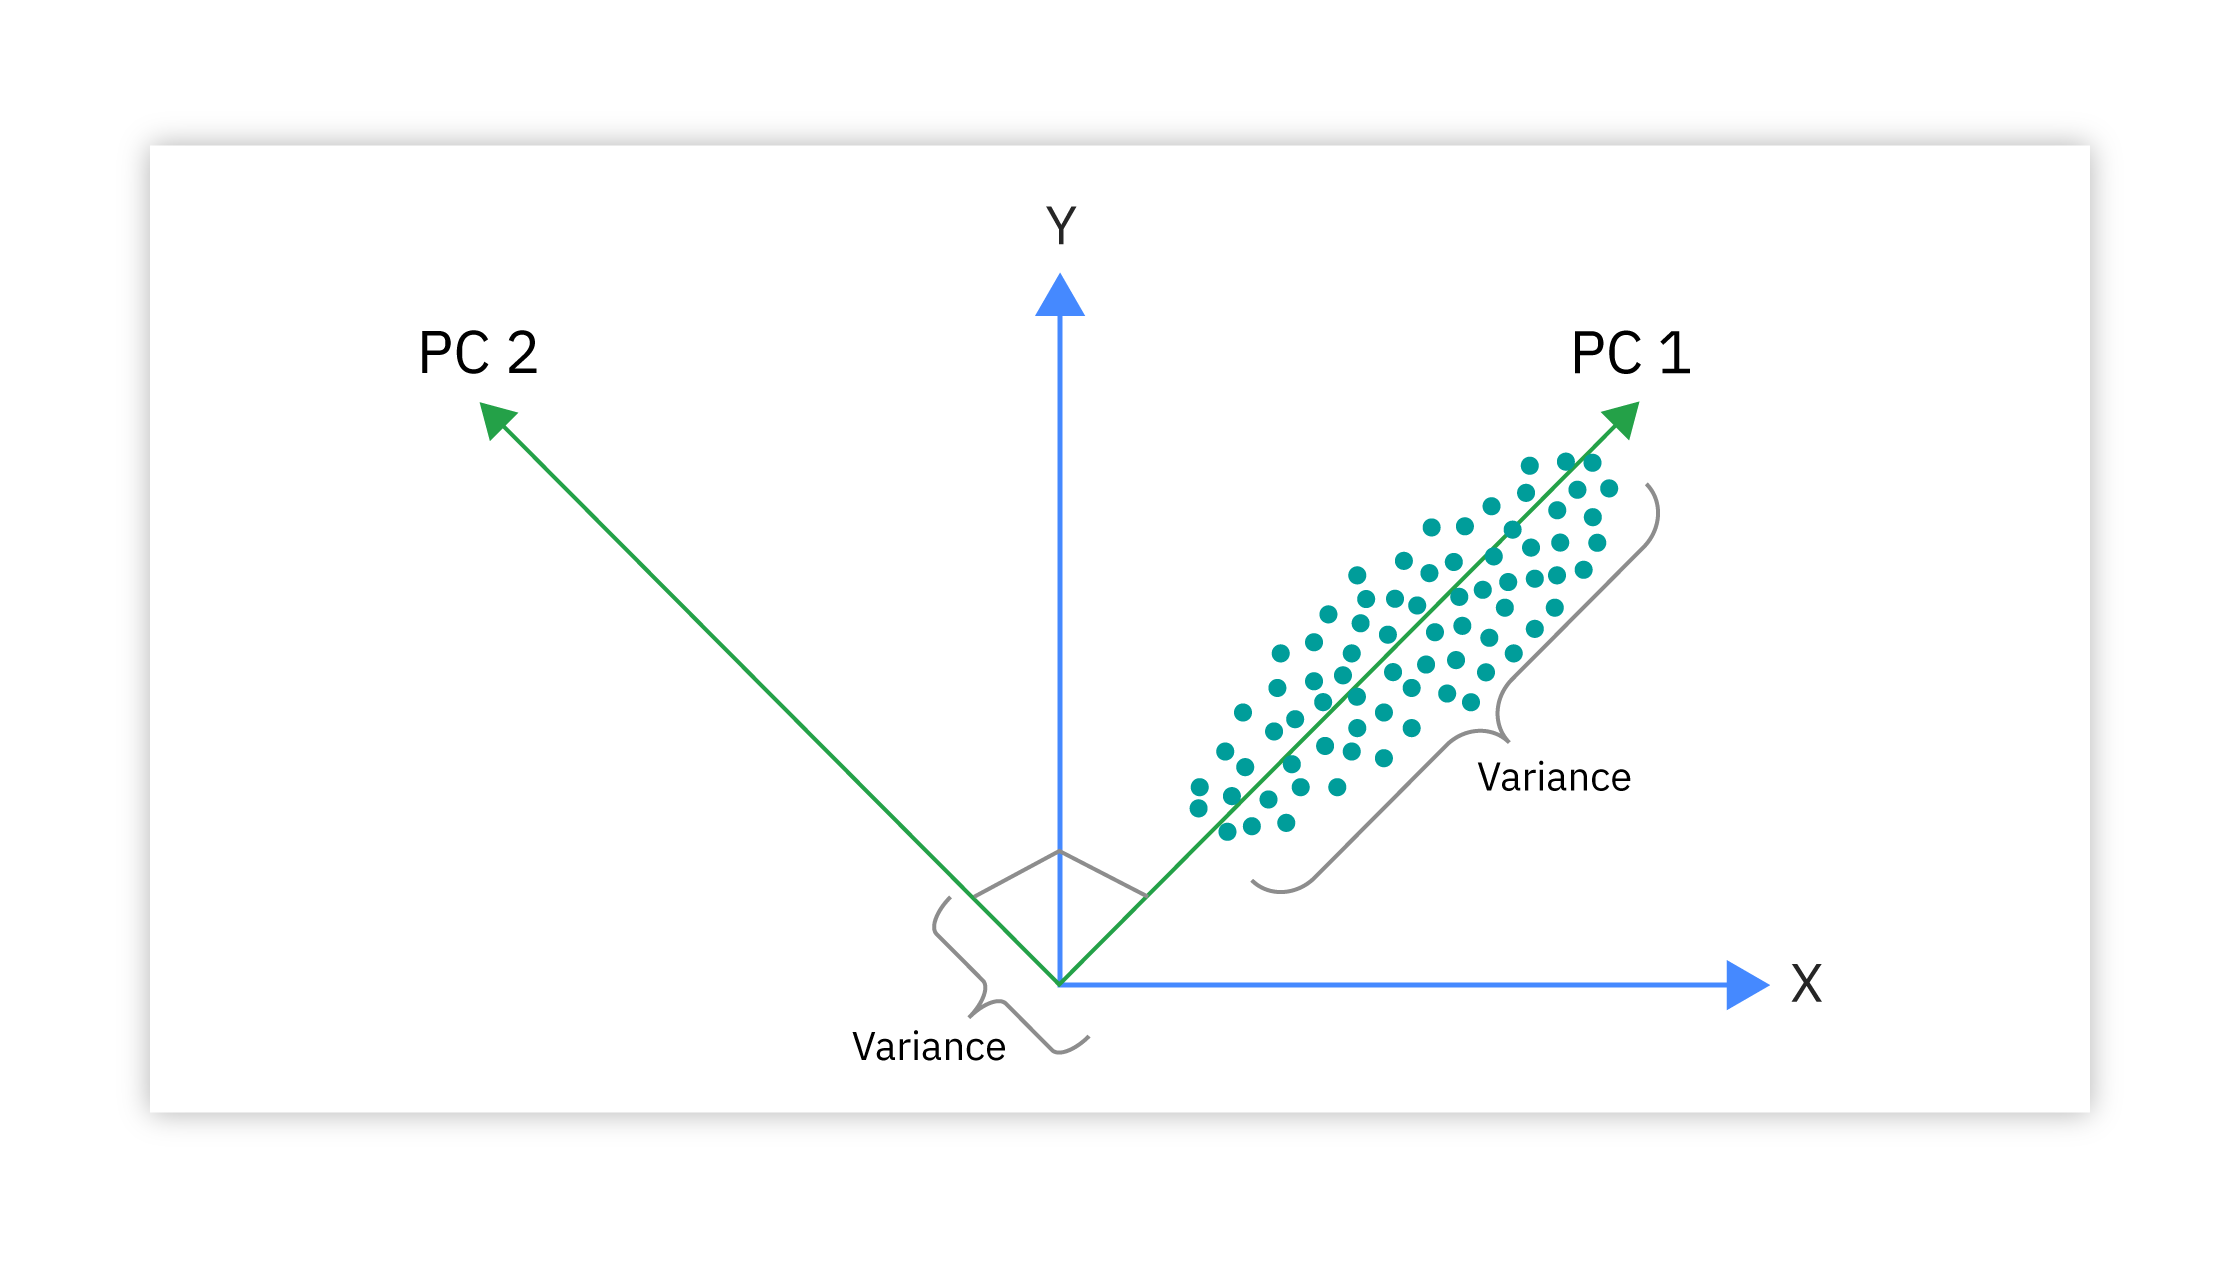

Let's compute the top 30 principal components:

In [ ]:
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, n_comps=30)

How much variance does each PC capture?

In [ ]:
sc.pl.pca_variance_ratio(adata_hvg, n_pcs=30)

Which principal components should we focus on?

In [ ]:
N_PCS = <your answer here>

#### Cluster and visualize

Now inspect the adata_hvg object. Where are principal components stored?

30 PCs are easier to work with than 32k genes, but it's still impossible for us to visualize data in 30 dimensions. Let's further reduce the dimensionality of the data to make it explorable on a plot.

In [ ]:
sc.pp.neighbors(adata_hvg, n_neighbors=10, n_pcs=N_PCS)
sc.tl.umap(adata_hvg)
sc.pl.umap(adata_hvg)

Do you notice any clusters of cells? How do they group?

Let's automtically assign clusters using an algorithm that creates groups based on the neighborhood graph:

In [ ]:
sc.tl.leiden(adata_hvg, resolution=0.5, random_state=0)
sc.pl.umap(adata_hvg, color="leiden", legend_loc="on data", frameon=False)

What do these clusters correspond to?

What if we try coloring by a gene of interest, example CD3D?

In [ ]:
sc.pl.umap(adata_hvg, color="CD3D", vmax=10)

Try recreating the UMAP and coloring it by CD14 expression (a monocyte marker)

Rerun leiden clustering, but set the resolution to 0.3. After doing this, plot the UMAP and color it by leiden cluster assignment. How many cells are in each cluster? (Hint, look at the cell metadata stored in .obs and use the pandas function .value_counts())

#### Save data

Next, get to know the AnnData documentation. Follow this link to read documentation about how to write an AnnData object to an h5ad file (this is an AnnData object's extension when you save it to a file):

https://anndata.readthedocs.io/en/latest/generated/anndata.AnnData.write_h5ad.html

Next, read the object into memory again. Find the function in the API ("application programming interface") documentation for reading .h5ad files into memory